In [1]:

# 1. This cell imports the necessary libraries, defines the core functions for segmenting the fMRI time-series data, calculates the autocorrelations, and builds our primary Pandas DataFrame.

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from scipy.io import loadmat
from scipy.stats import gaussian_kde
from statsmodels.tsa.stattools import acf

SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()

# Segments the data into segments of length 13 Tr 3 for the clip + 10 for the consolidation period
def create_segments_following_condition(data, conditions, intermediary_condition=0, preceding_conditions=(1, 2, 3)):
    segments = {cond: [] for cond in preceding_conditions}
    segment_start_index = None
    ongoing_condition = None
    last_condition_was_intermediary = False
    intermediary_count = 0
    for index, current_condition in enumerate(conditions):
        if current_condition in preceding_conditions:
            if ongoing_condition is None:
                segment_start_index = index
                ongoing_condition = current_condition
                intermediary_count = 0
            elif current_condition != ongoing_condition or last_condition_was_intermediary:
                if segment_start_index is not None:
                    segments[ongoing_condition].append(data[segment_start_index:index, :])
                    segment_start_index = index
                    ongoing_condition = current_condition
                    intermediary_count = 0
            last_condition_was_intermediary = False
        elif current_condition == intermediary_condition:
            if last_condition_was_intermediary:
                intermediary_count += 1
                if intermediary_count == 11:
                    if segment_start_index is not None:
                        segments[ongoing_condition].append(data[segment_start_index:index, :])
                        segment_start_index = None
                        ongoing_condition = None
                        intermediary_count = 0
            else:
                last_condition_was_intermediary = True
                intermediary_count = 1
        else:
            if last_condition_was_intermediary and segment_start_index is not None:
                segments[ongoing_condition].append(data[segment_start_index:index, :])
                segment_start_index = None
                ongoing_condition = None
            last_condition_was_intermediary = False
            intermediary_count = 0

    if ongoing_condition is not None and segment_start_index is not None:
        segments[ongoing_condition].append(data[segment_start_index:, :])

    return segments

# Calculates autocorrelations up to max_lag for each of the segments
def calculate_individual_acfs(segments, max_lag):
    acf_results = {}
    for cond, segs in segments.items():
        condition_acfs = []
        for seg in segs:
            segment_acfs = []
            for i in range(seg.shape[1]):
                feature_acf = acf(seg[:, i], nlags=max_lag, adjusted=True)
                segment_acfs.append(feature_acf)
            condition_acfs.append(np.array(segment_acfs))
        acf_results[cond] = condition_acfs
    return acf_results

# Aggregates acf metrics of independent segments into average acfs for a condition
def aggregate_acf_metrics(acf_results):
    aggregated_results = {}
    for cond, condition_acfs in acf_results.items():
        selected_acfs = condition_acfs
        all_acfs_selected = np.stack(selected_acfs)
        mean_acfs_selected = np.mean(all_acfs_selected, axis=0)
        std_acfs_selected = np.std(all_acfs_selected, axis=0)

        n = all_acfs_selected.size
        sterr_acfs_selected = std_acfs_selected / np.sqrt(n)

        aggregated_results[cond] = {
            'mean_acfs': mean_acfs_selected,
            'std_acfs': sterr_acfs_selected,
            'detailed_acfs': all_acfs_selected
        }
    return aggregated_results

# Retrieving data for participants and regions, calculating autocorrelations and storing them in a dataframe
participants = ['S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S15', 'S16', 'S17', 'S18']
combined_acf_by_participant = {}
regions = {'head': 0, 'tail': 1, 'body': 2}

data_by_participant = {}
segs_by_participant = {}
cond_by_participant = {}

for participant in participants:
    for HPC, region_code in regions.items():
        hpc_path = os.path.join(SCRIPT_DIR, f'data/allsubj_allrois_allruns_vxl_tsz/{participant}_LH_HPC_{HPC}_allruns_vxl_tsz.mat')
        mat = loadmat(hpc_path)
        voxelsxtimex = mat["vtsz"].T
        voxelsxtime = voxelsxtimex[:, ~np.isnan(voxelsxtimex).any(axis=0)]

        cnd_path = os.path.join(SCRIPT_DIR, f'data/allsubj_cnd_lbl/{participant}_allruns_cnd_lbl.mat')
        matx = loadmat(cnd_path)
        cndxrun = matx["cnd_lbl_xrun"].T
        cndacrossruns0 = cndxrun.ravel()
        cndacrossruns = cndacrossruns0[~np.isnan(cndacrossruns0)]
        max_lag = 5
        
        segments = create_segments_following_condition(voxelsxtime, cndacrossruns)
        
        individual_acfs = calculate_individual_acfs(segments, max_lag)
        aggregated_acf_metrics = aggregate_acf_metrics(individual_acfs)
        data_by_participant[(participant, region_code)] = voxelsxtime
        segs_by_participant[(participant, region_code)] = segments
        cond_by_participant[(participant, region_code)] = cndacrossruns
        combined_acf_by_participant[(participant, region_code)] = aggregated_acf_metrics

data_list = []
for (participant_id, region_code), conditions_data in combined_acf_by_participant.items():
    for condition, metrics in conditions_data.items():
        if 'mean_acfs' in metrics and 'std_acfs' in metrics:
            mean_acfs = metrics['mean_acfs']
            std_acfs = metrics['std_acfs']
            for lag in range(1, mean_acfs.shape[1]):
                for acf_value, std_dev in zip(mean_acfs[:, lag], std_acfs[:, lag]):
                    data_list.append({
                        'Participant': participant_id,
                        'HPC_Region': region_code,
                        'Condition': condition,
                        'Lag': lag,
                        'ACF_Value': acf_value,
                        'Std_Dev': std_dev
                    })

df = pd.DataFrame(data_list)

# --- MAP OF NUMERICAL VALUES ---
region_map = {0: 'Head', 1: 'Tail', 2: 'Body'}
condition_map = {1: 'Eventful Remembered', 2: 'Eventful Forgotten', 3: 'Uneventful'}

df['HPC_Region'] = df['HPC_Region'].map(region_map).fillna(df['HPC_Region'])
df['Condition'] = df['Condition'].map(condition_map).fillna(df['Condition'])

print("Data processing complete. DataFrame ready for visualization.")


Data processing complete. DataFrame ready for visualization.


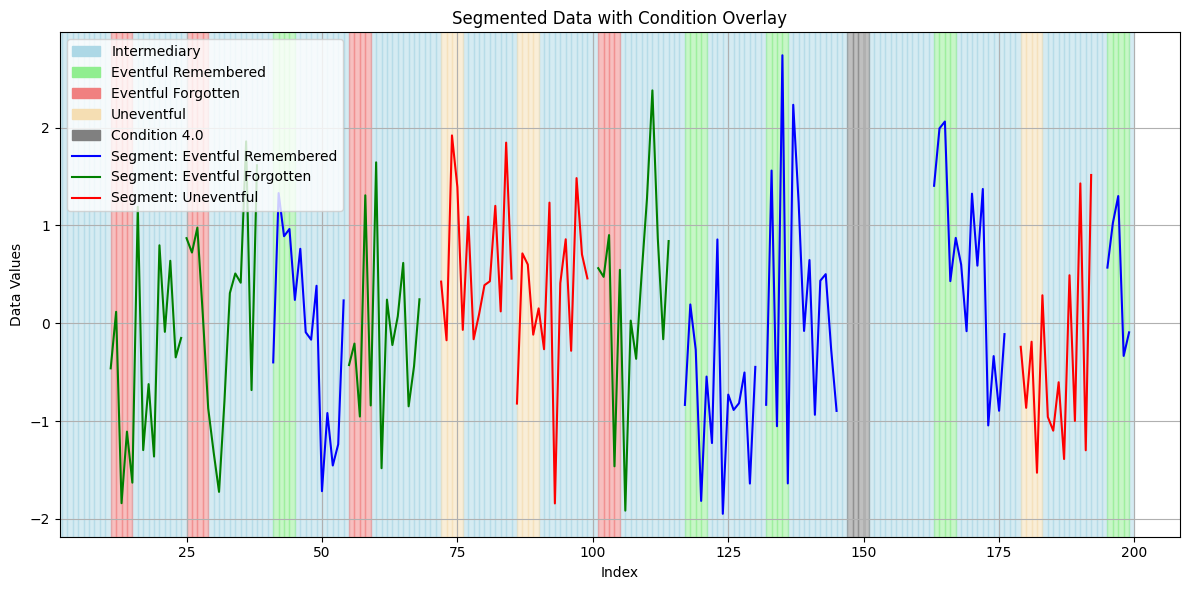

In [2]:
# 2. Used to plot the condition segmented data corresponding to an individual participant and selected region of the hippocampus 

def plot_segmented_data_with_conditions_overlay(data, segments, conditions, start_index=0, end_index=None):
    if end_index is None:
        end_index = len(data)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title('Segmented Data with Condition Overlay')
    ax.set_xlabel('Index')
    ax.set_ylabel('Data Values')

    condition_colors = {0: 'lightblue', 1: 'lightgreen', 2: 'lightcoral', 3: 'wheat'}
    cond_names_plot = {0: 'Intermediary', 1: 'Eventful Remembered', 2: 'Eventful Forgotten', 3: 'Uneventful'}
    
    unique_conditions = np.unique(conditions[start_index:end_index])
    condition_patches = []
    
    for condition in unique_conditions:
        color = condition_colors.get(condition, 'grey')
        cond_label = cond_names_plot.get(condition, f'Condition {condition}')
        condition_patches.append(mpatches.Patch(color=color, label=cond_label))
        cond_indices = np.where(conditions[start_index:end_index] == condition)[0]
        for idx in cond_indices:
            ax.axvspan(idx + start_index, idx + start_index + 1, color=color, alpha=0.5)
            
    colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']
    segment_color_map = {cond: colors[i % len(colors)] for i, cond in enumerate(segments.keys())}
    
    for cond, segs in segments.items():
        cond_label = cond_names_plot.get(cond, cond)
        for seg in segs:
            indices = np.where((data == seg[0]).all(axis=1))[0]
            if indices.size > 0:
                start_seg_index = indices[0]
                end_seg_index = start_seg_index + len(seg)
                if start_seg_index < end_index and end_seg_index > start_index:
                    plot_start = max(start_index, start_seg_index)
                    plot_end = min(end_index, end_seg_index)
                    ax.plot(range(plot_start, plot_end),
                            seg[plot_start - start_seg_index:plot_end - start_seg_index, 1],
                            color=segment_color_map[cond], label=f'Segment: {cond_label}')
                            
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(handles=condition_patches + list(by_label.values()),
              labels=[p.get_label() for p in condition_patches] + list(by_label.keys()), loc='upper left')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Select the participant and region you want to verify
participant_to_plot = 'S02'
region_to_plot = 0 # 0 = Head, 1 = Tail, 2 = Body

# Pull the specific data from the dictionaries created in Cell 1
participant_data = data_by_participant[(participant_to_plot, region_to_plot)]
participant_segments = segs_by_participant[(participant_to_plot, region_to_plot)]
participant_conditions = cond_by_participant[(participant_to_plot, region_to_plot)]

# Run the plot
plot_segmented_data_with_conditions_overlay(
    data=participant_data, 
    segments=participant_segments, 
    conditions=participant_conditions, 
    start_index=0, 
    end_index=200
)

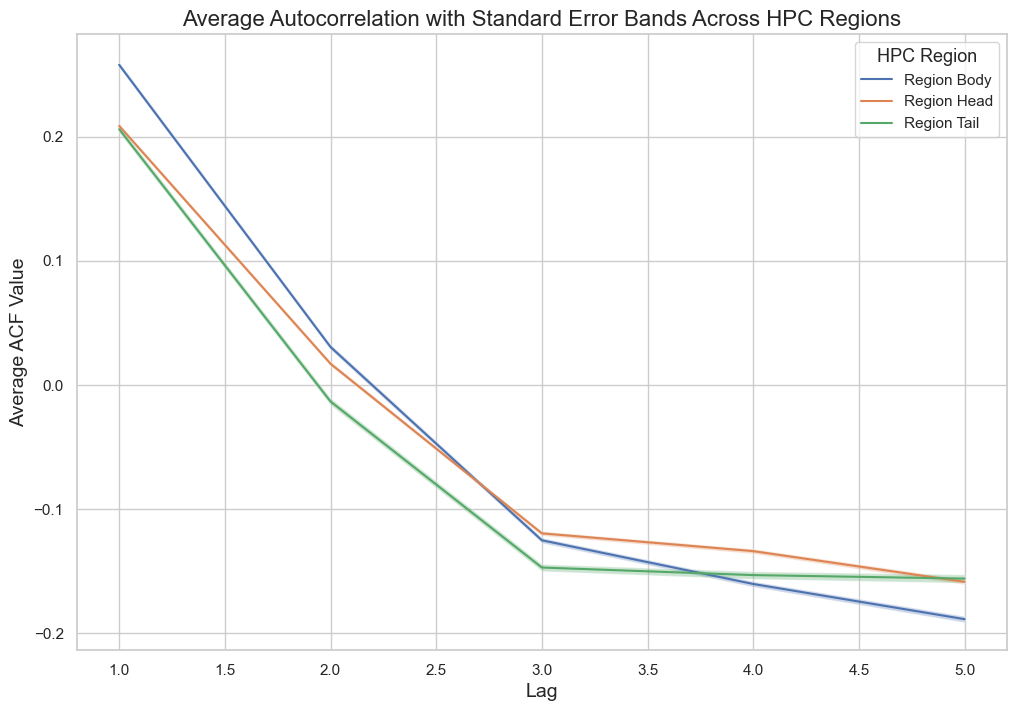

In [3]:
# 3. This plot compares the average decay in autocorrelation across the Head, Body, and Tail of the hippocampus, combining all experimental conditions to establish a baseline.

def plot_acf(dataframe):
    sns.set(style="whitegrid")
    acf_stats = dataframe.groupby(['HPC_Region', 'Lag']).agg({
        'ACF_Value': 'mean',
        'Std_Dev': 'mean' 
    }).reset_index()

    plt.figure(figsize=(12, 8))
    for region, group in acf_stats.groupby('HPC_Region'):
        plt.plot(group['Lag'], group['ACF_Value'], label=f'Region {region}')
        plt.fill_between(group['Lag'],
                         group['ACF_Value'] - group['Std_Dev'],
                         group['ACF_Value'] + group['Std_Dev'],
                         alpha=0.3)

    plt.title('Average Autocorrelation with Standard Error Bands Across HPC Regions', fontsize=16)
    plt.xlabel('Lag', fontsize=14)
    plt.ylabel('Average ACF Value', fontsize=14)
    plt.legend(title='HPC Region', title_fontsize='13', fontsize='11', loc='upper right')
    plt.show()

plot_acf(df)

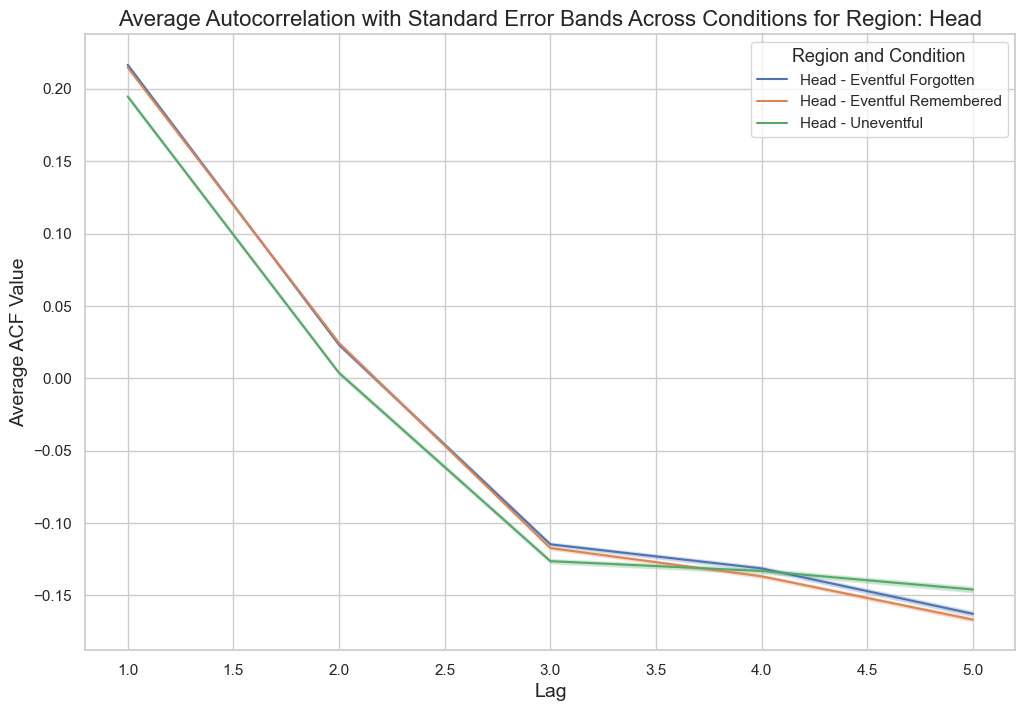

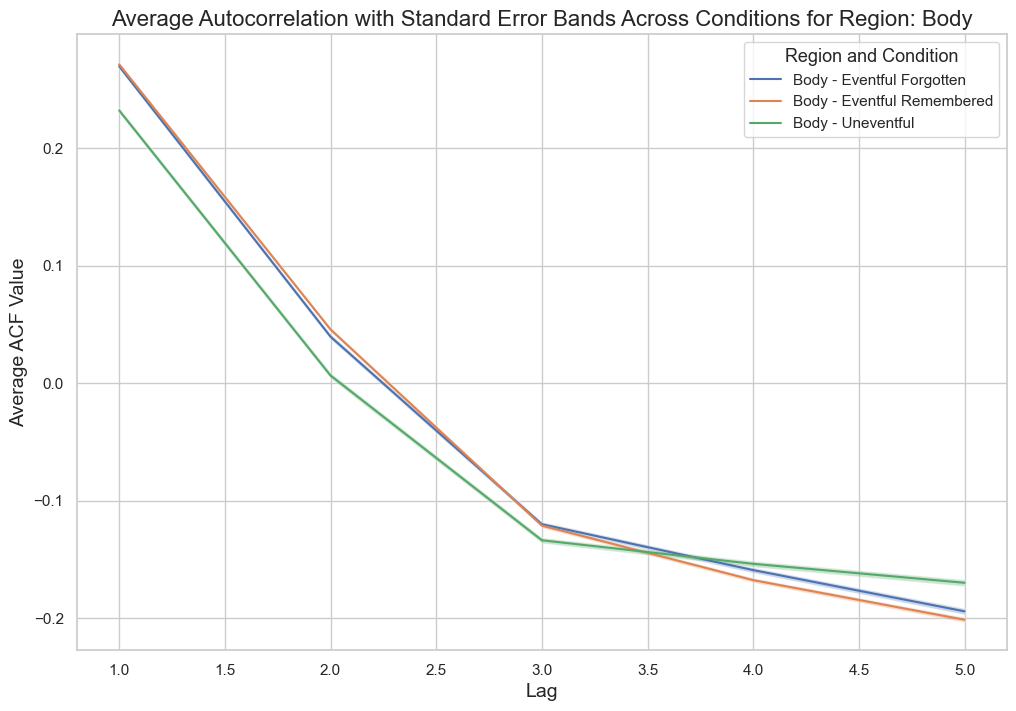

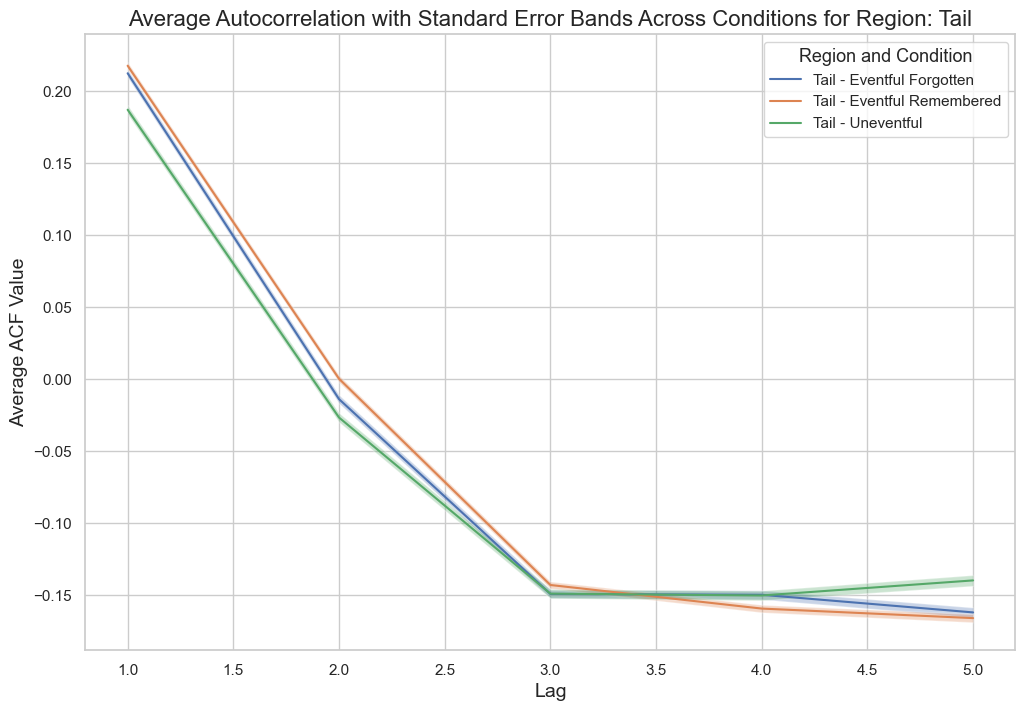

In [4]:
# 4. Next we isolate each region of the hippocampus to observe how the autocorrelation signatures differ depending on the cognitive task (Eventful Remembered, Eventful Forgotten, or Uneventful).

#%%
def plot_acf_single_plot(dataframe, hpc_region_name):
    sns.set(style="whitegrid")
    filtered_data = dataframe[dataframe['HPC_Region'] == hpc_region_name]
    acf_stats = filtered_data.groupby(['HPC_Region', 'Condition', 'Lag']).agg({
        'ACF_Value': 'mean',
        'Std_Dev': 'mean'
    }).reset_index()
    
    acf_stats['Region_Condition'] = acf_stats['HPC_Region'].astype(str) + " - " + acf_stats['Condition'].astype(str)

    plt.figure(figsize=(12, 8))
    for label, group in acf_stats.groupby('Region_Condition'):
        plt.plot(group['Lag'], group['ACF_Value'], label=label)
        plt.fill_between(group['Lag'],
                         group['ACF_Value'] - group['Std_Dev'],
                         group['ACF_Value'] + group['Std_Dev'],
                         alpha=0.3)

    plt.title(f'Average Autocorrelation with Standard Error Bands Across Conditions for Region: {hpc_region_name}', fontsize=16)
    plt.xlabel('Lag', fontsize=14)
    plt.ylabel('Average ACF Value', fontsize=14)
    plt.legend(title='Region and Condition', title_fontsize='13', fontsize='11', loc='upper right')
    plt.show()

plot_acf_single_plot(df, 'Head')
plot_acf_single_plot(df, 'Body')
plot_acf_single_plot(df, 'Tail')

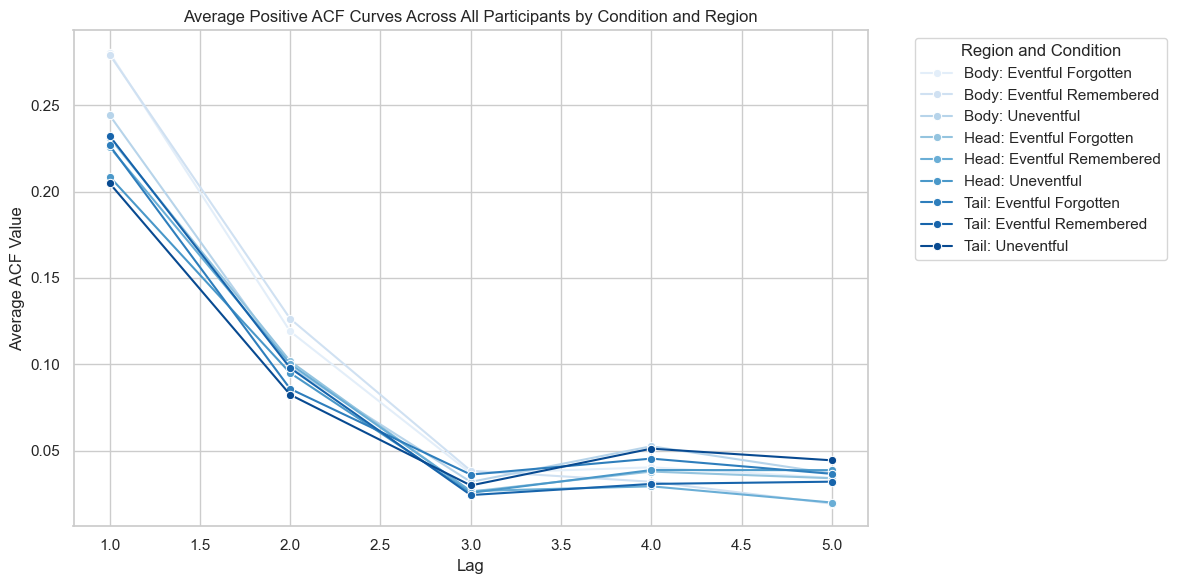

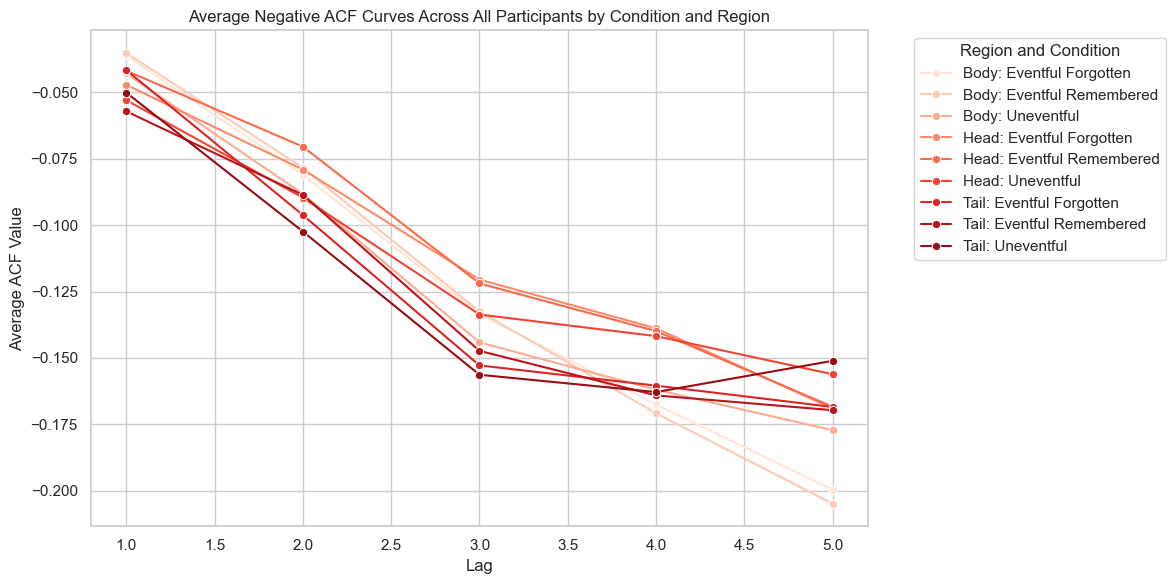

In [5]:
# 5. To better understand the distribution of signals, we split the feature means into purely positive and purely negative autocorrelation values across lags and conditions.

df['Sign'] = df['ACF_Value'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
avg_acf_by_sign = df.groupby(['HPC_Region', 'Condition', 'Lag', 'Sign'], as_index=False).agg({'ACF_Value': 'mean'})

avg_acf_by_sign['Region_Condition'] = avg_acf_by_sign['HPC_Region'].astype(str) + ": " + avg_acf_by_sign['Condition'].astype(str)

sns.set(style="whitegrid")
palette = {'Positive': 'Blues', 'Negative': 'Reds'}

for sign in ['Positive', 'Negative']:
    plt.figure(figsize=(12, 6))
    sign_data = avg_acf_by_sign[avg_acf_by_sign['Sign'] == sign]
    
    sns.lineplot(
        data=sign_data, 
        x='Lag', 
        y='ACF_Value', 
        hue='Region_Condition', 
        marker='o', 
        linestyle='-',
        palette=palette[sign] 
    )

    plt.legend(title='Region and Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f'Average {sign} ACF Curves Across All Participants by Condition and Region')
    plt.xlabel('Lag')
    plt.ylabel('Average ACF Value')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

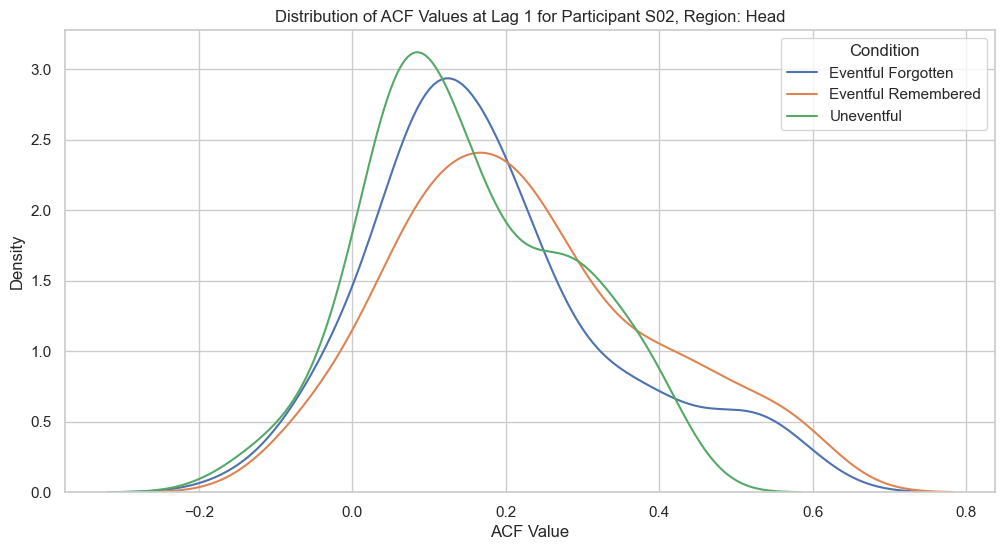

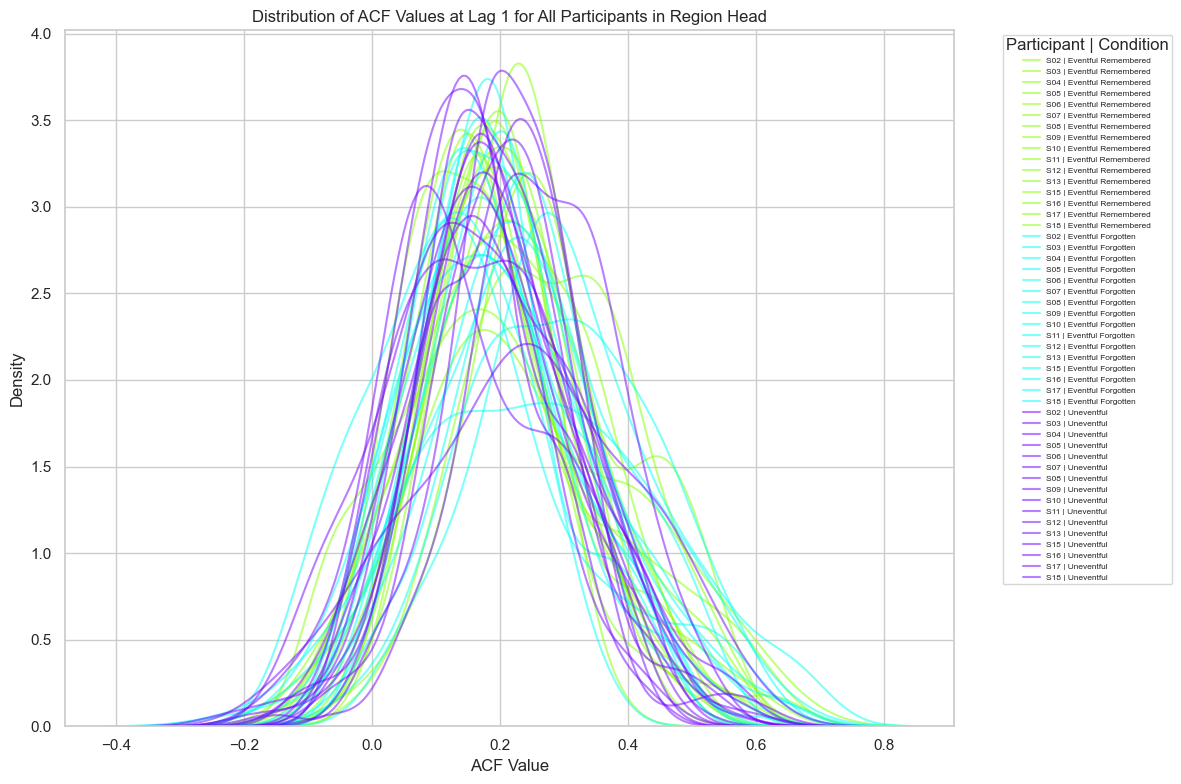

In [6]:
# 6. Moving away from line plots, these KDE plots show the actual density and distribution of ACF values at a specific lag (Lag 1) to visualize the variance between individuals and conditions.

def plot_acf_distributions_for_participant(df, participant_id, hpc_region_name, lag):
    df_filtered = df.loc[
        (df['Participant'] == participant_id) & (df['HPC_Region'] == hpc_region_name) & (df['Lag'] == lag)].copy()
    df_filtered['Condition'] = df_filtered['Condition'].astype('category')

    plt.figure(figsize=(12, 6))
    conditions = df_filtered['Condition'].cat.categories
    for condition in conditions:
        condition_data = df_filtered[df_filtered['Condition'] == condition]
        sns.kdeplot(condition_data['ACF_Value'], label=str(condition))
    plt.title(f'Distribution of ACF Values at Lag {lag} for Participant {participant_id}, Region: {hpc_region_name}')
    plt.xlabel('ACF Value')
    plt.ylabel('Density')
    plt.legend(title='Condition')
    plt.show()

def plot_individual_acf_distributions(df, hpc_region_name, lag):
    plt.figure(figsize=(12, 8))
    df_lag = df[(df['HPC_Region'] == hpc_region_name) & (df['Lag'] == lag)].copy()
    conditions = df_lag['Condition'].unique()
    color_palette = sns.color_palette("hsv", len(conditions))
    condition_color_map = dict(zip(conditions, color_palette))

    for condition in conditions:
        for participant_id in df_lag['Participant'].unique():
            participant_condition_df = df_lag[(df_lag['Participant'] == participant_id) & (df_lag['Condition'] == condition)]
            if not participant_condition_df.empty:
                sns.kdeplot(participant_condition_df['ACF_Value'],
                            color=condition_color_map[condition],
                            label=f'{participant_id} | {condition}', alpha=0.5)

    plt.title(f'Distribution of ACF Values at Lag {lag} for All Participants in Region {hpc_region_name}')
    plt.xlabel('ACF Value')
    plt.ylabel('Density')
    plt.legend(title='Participant | Condition', bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 6})
    plt.tight_layout()
    plt.show()

plot_acf_distributions_for_participant(df, 'S02', 'Head', 1)
plot_individual_acf_distributions(df, 'Head', 1)